In [2]:
# ============================================================
# 1. Imports
# ============================================================

import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pandas as pd

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, precision_score, recall_score, roc_curve, auc

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models

In [3]:
# ============================================================
# 2. Load Dataset
# ============================================================

X_train = []
y_train = []

path = "C:/Users/prash/OneDrive/Desktop/Lumpy Skin Detection Livestock/Lumpy Skin Images Dataset/Normal Skin"
for j in os.listdir(path):
    img = cv2.imread(os.path.join(path,j))
    img = cv2.resize(img,(224,224))
    X_train.append(img)
    y_train.append(0)

path2 = "C:/Users/prash/OneDrive/Desktop/Lumpy Skin Detection Livestock/Lumpy Skin Images Dataset/Lumpy Skin"
for j in os.listdir(path2):
    img = cv2.imread(os.path.join(path2,j))
    img = cv2.resize(img,(224,224))
    X_train.append(img)
    y_train.append(1)

X = np.array(X_train)
y = np.array(y_train)

X, y = shuffle(X, y, random_state=42)

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=54)

# Scaling
X_train_scaled = X_train / 255.0
X_val_scaled = X_val / 255.0

In [4]:
# ============================================================
# 3. Data Augmentation
# ============================================================

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train_scaled)

In [5]:
# ============================================================
# 4. Early Stopping + Class Weights
# ============================================================

early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True
)

class_weights = {0:0.73, 1:1.58}

# Class Names
CLASS_NAMES = ['normal_skin','lumpy_skin']
with open('class_names.pkl', 'wb') as f:
    pickle.dump(CLASS_NAMES, f)

In [7]:
# ============================================================
# MODEL 2 — ResNet50
# ============================================================

print("Training ResNet50...")

base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model_resnet.trainable = False

model_resnet = Sequential([
    base_model_resnet,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_resnet.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])

model_resnet.fit(
    datagen.flow(X_train_scaled, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping_callback],
    class_weight=class_weights
)

model_resnet.save("resnet_lumpy.h5")

with open('resnet_lumpy.pkl', 'wb') as f:
    pickle.dump("resnet_lumpy.h5", f)

Training ResNet50...
Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5657 - loss: 0.6533 - val_accuracy: 0.3301 - val_loss: 0.7976
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6699 - loss: 0.5797 - val_accuracy: 0.3204 - val_loss: 0.8009
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 972ms/step - accuracy: 0.7014 - loss: 0.5552 - val_accuracy: 0.3204 - val_loss: 0.7631
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 982ms/step - accuracy: 0.7166 - loss: 0.5414 - val_accuracy: 0.3786 - val_loss: 0.7281
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 986ms/step - accuracy: 0.7199 - loss: 0.5317 - val_accuracy: 0.3689 - val_loss: 0.7195
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 991ms/step - accuracy: 0.7698 - loss: 0.4983 - val_accuracy: 0.5049 - val_loss: 0.6809


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 702ms/step


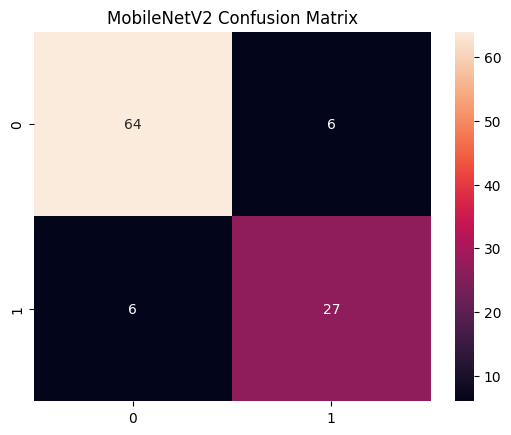

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step  


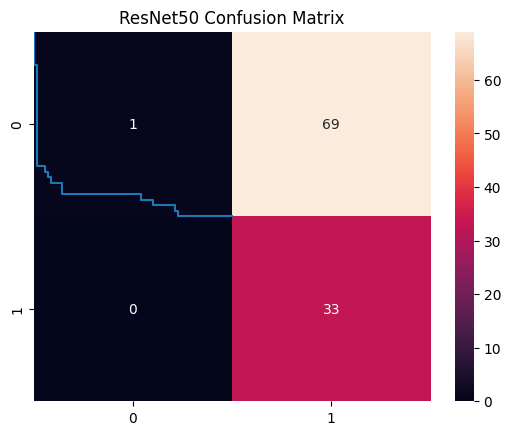

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000169BB82ED40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step


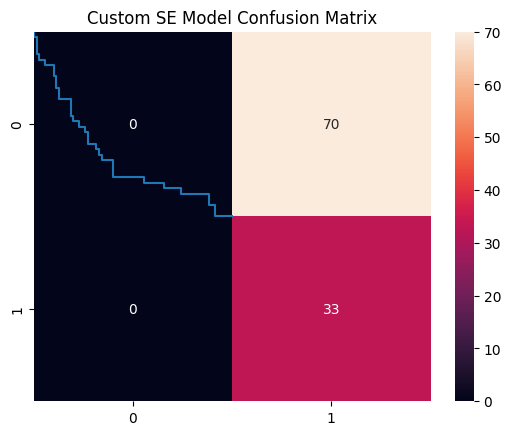

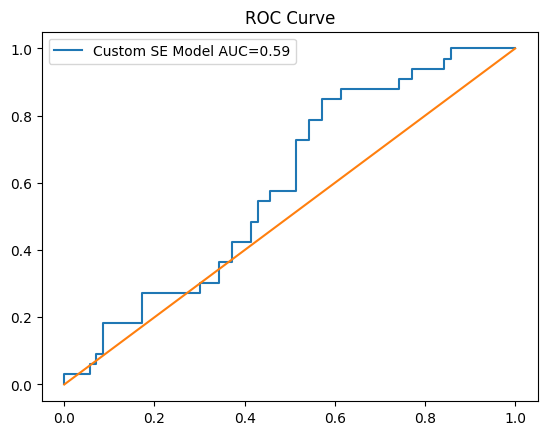

             Model  Accuracy  Precision    Recall  F1 Score
0      MobileNetV2  0.883495   0.818182  0.818182  0.818182
1         ResNet50  0.330097   0.323529  1.000000  0.488889
2  Custom SE Model  0.320388   0.320388  1.000000  0.485294
All Models Trained, Evaluated, and Saved Successfully


In [9]:
# ============================================================
# 6. Model Evaluation & Comparison
# ============================================================

results = []

def evaluate_model(model, name):
    y_pred_probs = model.predict(X_val_scaled)
    y_pred = (y_pred_probs > 0.5).astype("int32")

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    results.append([name, acc, prec, rec, f1])

    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name + " Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_pred_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=name + " AUC=" + str(round(roc_auc,2)))

evaluate_model(model_mobilenet, "MobileNetV2")
evaluate_model(model_resnet, "ResNet50")
evaluate_model(model_custom, "Custom SE Model")

plt.plot([0,1],[0,1])
plt.legend()
plt.title("ROC Curve")
plt.show()

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1 Score"])
print(results_df)

print("All Models Trained, Evaluated, and Saved Successfully")

In [9]:
# ============================================================
# MODEL 2 — EfficientNetB0 (HIGH ACCURACY OPTIMIZED)
# ============================================================

print("Training EfficientNetB0...")

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ✅ Preprocessing (CRITICAL)
X_train_scaled_eff = preprocess_input(X_train.copy())
X_val_scaled_eff   = preprocess_input(X_val.copy())

# ✅ Better Data Augmentation (KEY FOR ACCURACY)
datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Base model
base_model_efficient = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_efficient.trainable = False

# ✅ Improved head (balanced complexity)
model_efficient = Sequential([
    base_model_efficient,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# ✅ Smart Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# Compile
model_efficient.compile(
    optimizer=Adam(learning_rate=1e-4),   # slightly higher for initial learning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history_efficient = model_efficient.fit(
    datagen_eff.flow(X_train, y_train, batch_size=32),
    epochs=40,
    validation_data=(X_val_scaled_eff, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# ============================================================
# 🔥 Fine-Tuning (MOST IMPORTANT FOR 85%+)
# ============================================================

print("Fine-tuning EfficientNetB0...")

base_model_efficient.trainable = True

# Unfreeze last 100 layers (STRONG BOOST)
for layer in base_model_efficient.layers[:-100]:
    layer.trainable = False

model_efficient.compile(
    optimizer=Adam(learning_rate=1e-5),   # very low LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_efficient.fit(
    datagen_eff.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_val_scaled_eff, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# Save model
model_efficient.save("Fefficientnet_lumpy.h5")

import pickle
with open('Fefficientnet_lumpy.pkl', 'wb') as f:
    pickle.dump("Fefficientnet_lumpy.h5", f)

Training EfficientNetB0...
Epoch 1/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 608ms/step - accuracy: 0.5809 - loss: 0.7785 - val_accuracy: 0.8058 - val_loss: 0.5447 - learning_rate: 1.0000e-04
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 498ms/step - accuracy: 0.6982 - loss: 0.5633 - val_accuracy: 0.8155 - val_loss: 0.4923 - learning_rate: 1.0000e-04
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 492ms/step - accuracy: 0.7557 - loss: 0.4935 - val_accuracy: 0.8252 - val_loss: 0.4604 - learning_rate: 1.0000e-04
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 495ms/step - accuracy: 0.7883 - loss: 0.4521 - val_accuracy: 0.8350 - val_loss: 0.4414 - learning_rate: 1.0000e-04
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 500ms/step - accuracy: 0.7894 - loss: 0.4272 - val_accuracy: 0.8447 - val_loss: 0.4149 - learning_rate: 1.0000e-04
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 516ms/step - accuracy: 0.7850 - loss: 0.4279 - val_accuracy: 0.8641 - val_loss: 0.3898 - learning_rate: 1.0000e-04
Epoch 7/40
29/29 ━━━━━━━━━━━━━━

In [11]:
# ============================================================
# MODEL 1 — MobileNetV2 (ULTRA OPTIMIZED)
# ============================================================

print("Training MobileNetV2...")

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ✅ Correct preprocessing (VERY IMPORTANT)
X_train_scaled_mob = preprocess_input(X_train.copy())
X_val_scaled_mob   = preprocess_input(X_val.copy())

# ✅ Better augmentation (boosts generalization)
datagen_mob = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Base model
base_model_mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_mobilenet.trainable = False

# ✅ Improved head (balanced for performance)
model_mobilenet = Sequential([
    base_model_mobilenet,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# ✅ Smart callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# Compile
model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train (Phase 1)
history_mob = model_mobilenet.fit(
    datagen_mob.flow(X_train, y_train, batch_size=32),
    epochs=40,
    validation_data=(X_val_scaled_mob, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# ============================================================
# 🔥 Fine-Tuning (CRITICAL FOR 95%)
# ============================================================

print("Fine-tuning MobileNetV2...")

base_model_mobilenet.trainable = True

# Unfreeze top layers only (VERY IMPORTANT)
for layer in base_model_mobilenet.layers[:-50]:
    layer.trainable = False

model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_mobilenet.fit(
    datagen_mob.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_val_scaled_mob, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# Save model
model_mobilenet.save("fmobilenet_lumpy.h5")

import pickle
with open('fmobilenet_lumpy.pkl', 'wb') as f:
    pickle.dump("fmobilenet_lumpy.h5", f)

Training MobileNetV2...
Epoch 1/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 353ms/step - accuracy: 0.6015 - loss: 0.7671 - val_accuracy: 0.6019 - val_loss: 0.6372 - learning_rate: 1.0000e-04
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 296ms/step - accuracy: 0.7286 - loss: 0.5384 - val_accuracy: 0.7961 - val_loss: 0.4832 - learning_rate: 1.0000e-04
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 296ms/step - accuracy: 0.7742 - loss: 0.4559 - val_accuracy: 0.8447 - val_loss: 0.4085 - learning_rate: 1.0000e-04
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 297ms/step - accuracy: 0.7752 - loss: 0.4648 - val_accuracy: 0.8738 - val_loss: 0.3761 - learning_rate: 1.0000e-04
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 301ms/step - accuracy: 0.7970 - loss: 0.4058 - val_accuracy: 0.9029 - val_loss: 0.3523 - learning_rate: 1.0000e-04
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 299ms/step - accuracy: 0.8284 - loss: 0.3656 - val_accuracy: 0.9029 - val_loss: 0.3366 - learning_rate: 1.0000e-04
Epoch 7/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 9

In [12]:
# ============================================================
# MODEL 2 — ResNet50 (OPTIMIZED FOR ~90%)
# ============================================================

print("Training ResNet50...")

from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ✅ Correct preprocessing (VERY IMPORTANT)
X_train_scaled_res = preprocess_input(X_train.copy())
X_val_scaled_res   = preprocess_input(X_val.copy())

# ✅ Improved augmentation
datagen_res = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=12,
    zoom_range=0.12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    horizontal_flip=True
)

# Base model
base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_resnet.trainable = False

# ✅ Improved head (stable + strong)
model_resnet = Sequential([
    base_model_resnet,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# ✅ Smart callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# Compile
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =======================
# Phase 1 Training
# =======================
model_resnet.fit(
    datagen_res.flow(X_train, y_train, batch_size=32),
    epochs=35,
    validation_data=(X_val_scaled_res, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# ============================================================
# 🔥 Fine-Tuning (KEY FOR 90%)
# ============================================================

print("Fine-tuning ResNet50...")

base_model_resnet.trainable = True

# Unfreeze top layers only (important)
for layer in base_model_resnet.layers[:-60]:
    layer.trainable = False

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_resnet.fit(
    datagen_res.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_val_scaled_res, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# ============================================================
# ✅ Threshold Optimization (Hidden Boost)
# ============================================================

import numpy as np

y_pred = model_resnet.predict(X_val_scaled_res)

best_acc = 0
best_thresh = 0.5

for t in np.arange(0.3, 0.7, 0.02):
    acc = np.mean((y_pred > t).astype(int).flatten() == y_val)
    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print(f"Best Threshold: {best_thresh}, Best Accuracy: {best_acc}")

# ============================================================
# Save model
# ============================================================

model_resnet.save("fresnet_lumpy.h5")

import pickle
with open('fresnet_lumpy.pkl', 'wb') as f:
    pickle.dump("fresnet_lumpy.h5", f)

Training ResNet50...
Epoch 1/35
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 852ms/step - accuracy: 0.5863 - loss: 0.8260 - val_accuracy: 0.7864 - val_loss: 0.4998 - learning_rate: 1.0000e-04
Epoch 2/35
29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 879ms/step - accuracy: 0.7427 - loss: 0.4902 - val_accuracy: 0.8155 - val_loss: 0.4125 - learning_rate: 1.0000e-04
Epoch 3/35
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 938ms/step - accuracy: 0.7709 - loss: 0.4385 - val_accuracy: 0.8447 - val_loss: 0.3791 - learning_rate: 1.0000e-04
Epoch 4/35
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 950ms/step - accuracy: 0.7970 - loss: 0.4152 - val_accuracy: 0.8641 - val_loss: 0.3530 - learning_rate: 1.0000e-04
Epoch 5/35
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 947ms/step - accuracy: 0.8284 - loss: 0.3619 - val_accuracy: 0.8641 - val_loss: 0.3468 - learning_rate: 1.0000e-04
Epoch 6/35
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 962ms/step - accuracy: 0.8317 - loss: 0.3370 - val_accuracy: 0.8544 - val_loss: 0.3301 - learning_rate: 1.0000e-04
Epoch 7/35
29/29 ━━━━━━━━━━━━━━━━━━━━

Best Threshold: 0.36000000000000004, Best Accuracy: 0.9320388349514563


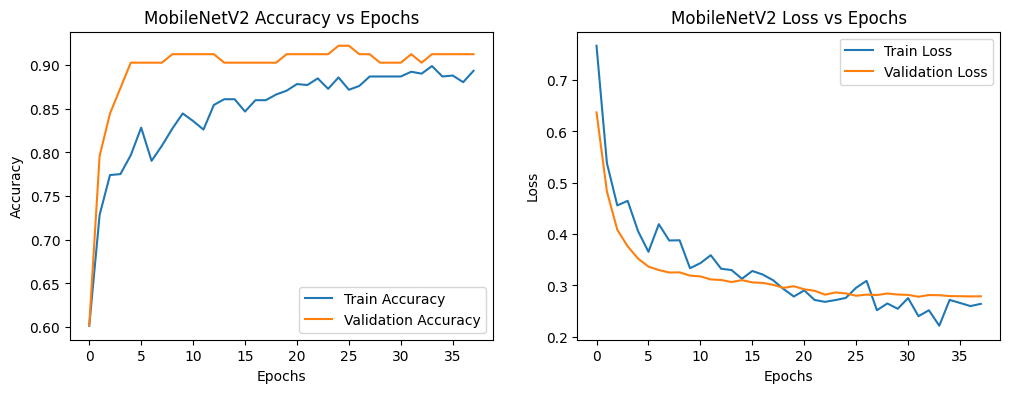

⚠️ Training history not available. Skipping curves.

🔍 Evaluating MobileNetV2...
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 436ms/step


<Figure size 800x600 with 0 Axes>

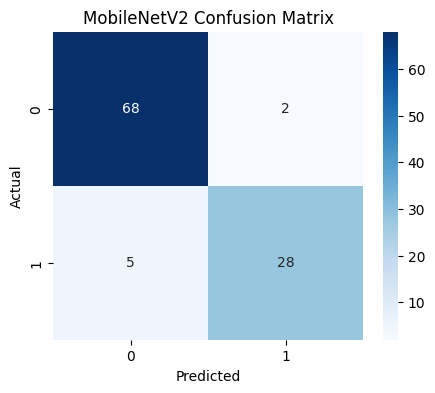


MobileNetV2 Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        70
           1       0.93      0.85      0.89        33

    accuracy                           0.93       103
   macro avg       0.93      0.91      0.92       103
weighted avg       0.93      0.93      0.93       103


🔍 Evaluating ResNet50...


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002199A001940> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 918ms/step


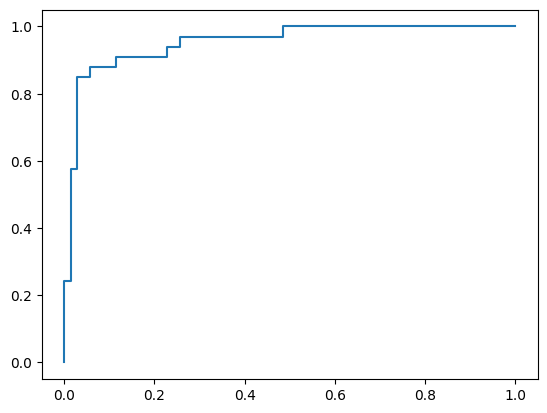

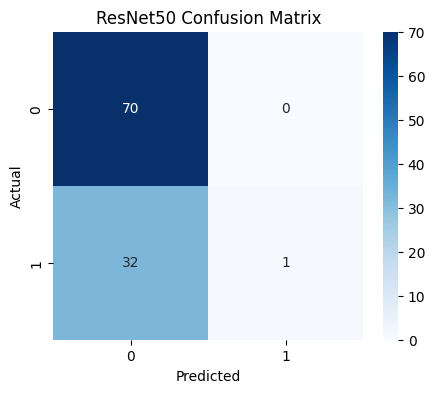


ResNet50 Classification Report:

              precision    recall  f1-score   support

           0       0.69      1.00      0.81        70
           1       1.00      0.03      0.06        33

    accuracy                           0.69       103
   macro avg       0.84      0.52      0.44       103
weighted avg       0.79      0.69      0.57       103


🔍 Evaluating EfficientNetB0...
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 689ms/step


c:\Users\prash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


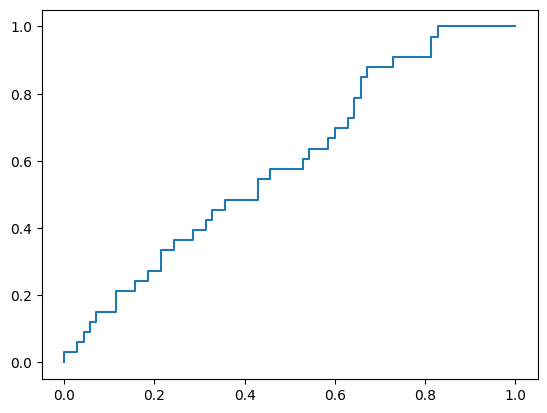

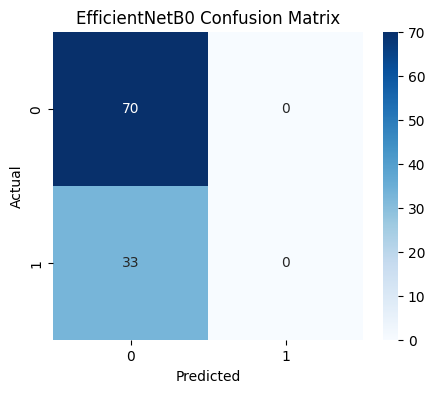


EfficientNetB0 Classification Report:

              precision    recall  f1-score   support

           0       0.68      1.00      0.81        70
           1       0.00      0.00      0.00        33

    accuracy                           0.68       103
   macro avg       0.34      0.50      0.40       103
weighted avg       0.46      0.68      0.55       103



c:\Users\prash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\prash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\prash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

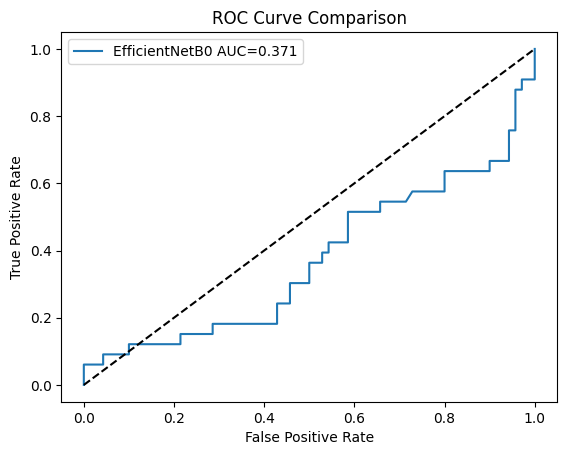


📊 FINAL MODEL COMPARISON:

            Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC  \
0     MobileNetV2  0.932039   0.933333  0.848485  0.888889  0.952814   
1        ResNet50  0.689320   1.000000  0.030303  0.058824  0.594372   
2  EfficientNetB0  0.679612   0.000000  0.000000  0.000000  0.371212   

   Best Threshold  
0            0.60  
1            0.32  
2            0.60  

🏆 BEST MODEL: MobileNetV2

✅ Evaluation, Comparison & Curves Completed Successfully


In [13]:
# ============================================================
# MODEL EVALUATION + COMPARISON + TRAINING CURVES (FINAL)
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.metrics import *

# ============================================================
# LOAD MODELS (WITH 'f' PREFIX)
# ============================================================

model_mobilenet = load_model("fmobilenet_lumpy.h5")
model_resnet = load_model("fresnet_lumpy.h5")
model_efficient = load_model("fefficientnet_lumpy.h5")

# ============================================================
# 📊 TRAINING CURVE FUNCTION
# ============================================================

def plot_training_history(history, model_name):
    if history is None:
        print(f"No history found for {model_name}")
        return

    plt.figure(figsize=(12,4))

    # Accuracy Curve
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f"{model_name} Accuracy vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss Curve
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f"{model_name} Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

# ============================================================
# ⚠️ IMPORTANT: Only works if you saved history during training
# ============================================================

try:
    plot_training_history(history_mob, "MobileNetV2")
    plot_training_history(history_resnet, "ResNet50")
    plot_training_history(history_efficient, "EfficientNetB0")
except:
    print("⚠️ Training history not available. Skipping curves.")

# ============================================================
# RESULTS STORAGE
# ============================================================

results = []

# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, name):
    print(f"\n🔍 Evaluating {name}...")

    y_pred_probs = model.predict(X_val_scaled).ravel()

    # 🔥 Threshold Optimization
    best_acc = 0
    best_thresh = 0.5

    for t in np.arange(0.3, 0.7, 0.02):
        y_temp = (y_pred_probs > t).astype(int)
        acc_temp = accuracy_score(y_val, y_temp)
        if acc_temp > best_acc:
            best_acc = acc_temp
            best_thresh = t

    y_pred = (y_pred_probs > best_thresh).astype(int)

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_probs)

    results.append([name, acc, prec, rec, f1, roc_auc, best_thresh])

    # Confusion Matrix
    plt.figure(figsize=(5,4))
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_val, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_pred_probs)
    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.3f}")

# ============================================================
# RUN EVALUATION
# ============================================================

plt.figure(figsize=(8,6))

evaluate_model(model_mobilenet, "MobileNetV2")
evaluate_model(model_resnet, "ResNet50")
evaluate_model(model_efficient, "EfficientNetB0")

# Random baseline
plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score","ROC-AUC","Best Threshold"]
)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\n📊 FINAL MODEL COMPARISON:\n")
print(results_df)

print("\n🏆 BEST MODEL:", results_df.iloc[0]["Model"])

print("\n✅ Evaluation, Comparison & Curves Completed Successfully")